# Exercise 4 - LLM Inference
_By Georg Ahnert_

In this exercise you will work with [Hugging Face Transformers](https://huggingface.co/docs/transformers/index) and [vllm](https://docs.vllm.ai/en/stable/index.html) to use generative language models for text annotation. We will focus on open-weight models that can be run locally (if you have a GPU available).

Note that the models we will use in this exercise are significantly larger (>1B parameters) than, e.g., distilbert (67M parameters). <br>
**This means that you will likely need to run this notebook on the BWUniCluster to have enough GPU memory and compute.**

This exercise consists of five parts:
1. Running generative models with Hugging Face Transformers
2. Running instruction-tuned (chat) models with Hugging Face Transformers
3. Running instruction-tuned models with vllm
5. Structured outputs

### Setup


#### First-time Setup on BWUniCluster3.0
If you run notebooks for the first time on the BWUniCluster3.0, you'll have to do some initial setup.

First, make sure that you have started a `minimal` jupyter instance as **starting an `ai` instance will likely lead to package conflicts!** Once the instance is started, open a new Terminal tab. Then, create a virtual environment (similar to a conda environment) and activate the environment like this:

```bash
python -m venv llm4ess_env
source llm4ess_env/bin/activate
```

Next, we need to install the minimum requirements for using our new environment as a kernel for Jupyter Notebooks. And finally, we can create a kernel based on this environment:

```bash
pip install ipykernel ipywidgets
python -m ipykernel install --user --name llm4ess --display-name "Python (LLM4ESS)" 
```

Now you can close the terminal and reload the browser window. The new kernel named `Python (LLM4ESS)` should now show up in the drop-down menu on the top right of your jupyter notebook.

Next, we have to install some additional dependencies - this step is required on both Google Colab and on the BWUniCluster and might take a while...

In [1]:
%%capture
%pip install vllm # note that vllm also installs many dependencies such as transformers, torch, pydantic etc.
%pip install seaborn

## Part 0: Queuing SLURM Jobs

The BWUniCluster uses SLURM as a job scheduler to allow many people access to the same compute nodes, without conflicts such as one job requesting too much memory and crashing another job through this.
Interactive Jupyter notebooks have a shorter runtime (4h max) and can only be started between 8am and 8pm every weekday. Outside of this window, and for longer jobs, you have to use SLURM and put your jobs into one of the available queues.

To start a job, you first have to create a bash script with special variables. See `example.slurm` as an example.

Simply start the job with `sbatch example.slurm`.

To see which of your jobs are currently queued or running, use `squeue`.

To see available queues ("partitions"), use `sinfo_t_idle`.

To cancel a running or failed job, use `scancel JOBID`.

## Part 1: Running Generative Models with 🤗 Transformers

First, let's import the required classes from Hugging Face Transformers and initialize our model.

Here, we use [Qwen/Qwen3.5-4B-Base](https://huggingface.co/Qwen/Qwen3.5-4B-Base), an open-weight language model from Alibaba. We can simply initialize it by its Hugging Face model name and the transformers library will take care of the rest (downloading the model, etc.).

Note that Qwen/Qwen3.5-4B-Base is a base model, i.e., it is trained to complete text input, not to engage in a dialog with the user. We'll have a look at instruction-tuned models later.

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.trainer_utils import set_seed
import torch

set_seed(42) # set a fixed seed for reproducibility

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-4B-Base")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3.5-4B-Base")

model = model.to('cuda') # load the model onto the GPU

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

We should now have the model successfully loaded in the GPU – let's have a look…

In [3]:
!nvidia-smi  # this is a command line tool that gives you an overview over your current GPU usage

Wed Sep 30 09:32:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:19:00.0 Off |                    0 |
| N/A   39C    P0             70W /  300W |    8572MiB /  81920MiB |     11%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

To make use of our language model, we need to provide it with some text input. Let's convert some texts into tokens…

In [4]:
message = ["The University of Mannheim is "]
inputs = tokenizer(message, return_tensors='pt', return_token_type_ids=False)
inputs

{'input_ids': tensor([[   760,   3694,    314, 230111,    369,    220]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

After moving our tokens to the GPU as well, we can generate text completions.
Note that is is important to have both the model and the input tokens on the same device.

In [5]:
inputs = {k: v.to('cuda') for k,v in inputs.items()}

response = model.generate(**inputs, max_new_tokens=100, do_sample=True, top_k=50, top_p=0.95)
response

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `fused_recurrent_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


tensor([[   760,   3694,    314, 230111,    369,    220,     22,   4276,    539,
          31432,    494,  53330,  20065,     11,    321,    424,    369,    220,
             16,     16,     15,   4276,   3023,    539,   5257,     13,    198,
             18,     13,    733,    780,   2018,   4952,     11,   1801,    383,
            220,     18,   6492,     11,    551,  10661,    421,    279,   5559,
           6306,    279,  11889,   1801,    383,    220,     17,     22,   6324,
            220,     17,     15,     15,     21,  17765,    279,  10660,  39254,
            310,    279,  18576,    314,  12968,    220,     19,     18,     23,
            310,    381,    328,     85,   4511,    487,    328,    258,    986,
          18558,      1,    321,    328,  10545,   7243,   2825,   3158,    198,
           2523,    599,    220,     20,   4276,    310,   1423,   1396,   3542,
            383,    279,   6220,     11,   1396,   6365,    314]],
       device='cuda:0')

Finally, we can de-code the tokens that we got in response and examine the text. It's probably not very impressive yet, though.

In [6]:
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is 7 minutes by taxi from Frankfurt Airport, and it is 110 minutes away by train.
3. In his second statement, made on 3 November, he stated that the Group considered the statements made on 27 October 2006 concerning the proposed amendments to the provisions of Article 438 to be "vague", "inadequate" and "unsatisfactory".
You have 5 minutes to find every character on the floor, every piece of


Let's try out some other generation parameters:

In [7]:
print('--- greedy decoding ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=False)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

print('\n--- temperature 0.1 ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=0.1)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

print('\n--- temperature 1.0 ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=1.0)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

print('\n--- temperature 2.0 ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=2.0)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

--- greedy decoding ---
The University of Mannheim is 100% German and offers a wide range of courses in the fields of economics, business administration, law, and social sciences. The university is known for its strong focus on research and teaching, with a particular emphasis on the social sciences. It is a member of the German Excellence Initiative and the Helmholtz Association, and it has a significant presence in the field of economics and business administration. The university offers a variety of programs, including a Master's in Economics and Business Administration, which

--- temperature 0.1 ---
The University of Mannheim is 10 minutes away by car from the airport.
The first step is to find out what the problem is.
The first step is to find out what the problem is.
The first step is to find out what the problem is.
The first step is to find out what the problem is.
The first step is to find out what the problem is.
The first step is to find out what the problem is.
The first s

We can also investigate the probabilities of each token in the vocabulary at each step of the output:

In [8]:
response = model.generate(**inputs, max_new_tokens=100, do_sample=False, return_dict_in_generate=True, output_logits=True)
response.logits[0][0] # first token in output and first output in batch

tensor([-0.3418, -2.0312, -0.9062,  ..., -3.4062, -3.4062, -3.4062],
       device='cuda:0')

In [9]:
# response.logits has shape: (seq_len, batch_size, vocab_size)
for step, step_logits in enumerate(response.logits[:5], start=1):

    print(f"--- Step {step} ---")
    
    log_probs = torch.nn.functional.softmax(step_logits[0], dim=-1) # apply softmax to convert to probabilities
    
    topk = torch.topk(log_probs, k=10) # extract the 10 most likely tokens at each step
    top_ids = topk.indices.tolist()
    top_scores = topk.values.tolist()

    for tok_id, score in zip(top_ids, top_scores):
        tok = tokenizer.decode(tok_id)
        print(f"'{tok}': {score:.3f}", end=', ')
    
    print('\n')


--- Step 1 ---
'1': 0.344, '2': 0.184, '3': 0.112, '5': 0.077, '4': 0.077, '6': 0.053, '7': 0.047, '8': 0.041, '9': 0.036, '0': 0.013, 

--- Step 2 ---
'0': 0.153, '2': 0.093, '.': 0.093, '5': 0.093, '1': 0.072, '3': 0.072, '4': 0.064, '8': 0.064, '6': 0.064, '7': 0.056, 

--- Step 3 ---
' minutes': 0.274, '0': 0.274, ' km': 0.129, '.': 0.061, '5': 0.025, ' miles': 0.016, '1': 0.014, '2': 0.014, '3': 0.014, '6': 0.014, 

--- Step 4 ---
'%': 0.257, ' km': 0.137, ' percent': 0.137, ' %': 0.121, ' years': 0.074, ' m': 0.037, '0': 0.033, ' meters': 0.025, ' metres': 0.021, ' minutes': 0.020, 

--- Step 5 ---
' German': 0.084, ' accredited': 0.070, ' online': 0.055, ' committed': 0.055, ' funded': 0.042, ' private': 0.031, ' dedicated': 0.027, ' tuition': 0.024, ' student': 0.021, ' independent': 0.020, 



### Task 1: Try out the impact of temperature and top_k in combination. What do you observe in the generated text?

In [10]:
### Low temperature is similar to greedy decoding (independent of top_k)
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=0.1, top_k=5)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is 10 minutes away by car from the airport.
The first thing you need to do is to download the latest version of the program.
The most common causes of this disease are :
The first thing you need to do is to download the latest version of the program.
The first thing you need to do is to download the latest version of the program.
The most common causes of this disease are :
The first thing you need to do is to download the latest version of the


In [11]:
### High temperature and high top_k leads to gibberish in the output
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=2.0, top_k=500)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is  The online economics journals pages, starting Vol.- 15, can easily guide you, maybe only a couple by opening academic articles require information about German license links are not submitted cover but DOI is necessary step might have their system the 'same approach', Etextbooks With resources available include is required, its content having numbers for higher, go as cover-and-version statements publish online. At an attempt publisher) from content article search part i] where pre articles per a non pay I...] this step,


In [12]:
### High temperature and low top_k leads to diverse, yet somewhat readable output
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=2.0, top_k=5)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is 500 m from the centre of the historic district of Neckargemünd, 3.7 km from Neckargmünster, 21 km from the centre of Karlsruhe and 52 km from the centre of Heidelberg. The nearest airport is Karlsruhe/Bad-Baden, 30 km away.
The 18th-century palace is surrounded by a 19th-century park that includes the 165-metre-high Tower House, which houses a restaurant


## Part 2: Running Chat Models with 🤗 Transformers

    Important: Restart your Python kernel now to clear the GPU memory

The base version of Qwen3.5-4B wasn't exactly helpful, because we couldn't easily ask a question. Let's try out the instruction-tuned/reasoning version instead.

In [2]:
from transformers import pipeline
from transformers.trainer_utils import set_seed

set_seed(42) # set a fixed seed for reproducibility

# pipelines are a higher-level abstraction offered by the transformers library
# they can be used with both base models and instruction-tuned models
pipe = pipeline("text-generation", model="Qwen/Qwen3.5-4B", max_length=None)

# also notice how the device was automatically set to 'cuda', i.e., the GPU

messages = [{"role": "user", "content": "Who are you?"}]
pipe(messages, tokenizer_encode_kwargs={"enable_thinking": False}) # disable reasoning for now to reduce output token production

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `fused_recurrent_gated_delta_rule` is falling back t

[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': 'I am **Qwen3.5**, the latest large language model developed by Tongyi Lab. I am designed to assist with a wide range of tasks, including answering questions, creating content, logical reasoning, coding, and analyzing complex documents. How can I help you today?\n'}]}]

Great, we have a working chat model now that we can ask to answer our questions or to perform tasks such as text annotation. We can use messages with different roles for system, and user prompts.

In [2]:
messages = [
    {"role": "system", "content": "You are a pirate."},
    {"role": "user", "content": "Describe yourself"}
]
pipe(messages, tokenizer_encode_kwargs={"enable_thinking": False})[0]['generated_text']

[{'role': 'system', 'content': 'You are a pirate.'},
 {'role': 'user', 'content': 'Describe yourself'},
 {'role': 'assistant',
  'content': "Ah, ye be askin' aye about the crew's captain? Very well, ye landlubber! Pull up a barrel and listen close, for I be a tale of salt, steel, and swashbucklin' glory.\n\nI be a **bloody-minded buccaneer** who's sailed the seven seas since the King's Navy turned their noses up at my ship, the *Iron Galleon*. I've parted company with gullies of silver, plundered the merchant fleets of the Dutch and the Spanish, and once—just once—broke the hull of a pirate ship with my bare hands! (Though I did knock out the captain first, so the crew was happy).\n\nMy cutlass is sharp as a shark's tooth, and my beard's long enough to hang a lantern from. I don't care for gold or jewels; I prefer a fine vintage rum, a good meal, and the thrill of a chase across the horizon. I'm a man of few words and many scars, but my heart be big as a drum and my laugh be loud enoug

We can also pre-define previous `assistant` answers. This can be helpful for few-shot prompting – notice how the LLM adopts our answer template in the following example:

In [3]:
messages = [
    {"role": "system", "content": "You are an expert mathematician."},
    {"role": "user", "content": "What is 4+4?"},
    {"role": "assistant", "content": "The answer is 8."},
    {"role": "user", "content": "What is 49/7?"}
]
pipe(messages, tokenizer_encode_kwargs={"enable_thinking": False})[0]['generated_text']

[{'role': 'system', 'content': 'You are an expert mathematician.'},
 {'role': 'user', 'content': 'What is 4+4?'},
 {'role': 'assistant', 'content': 'The answer is 8.'},
 {'role': 'user', 'content': 'What is 49/7?'},
 {'role': 'assistant', 'content': 'The answer is 7.\n'}]

Under the hood, the model still generates tokens first, which are then automatically decoded and parsed into a list of dictionaries. Notice how the output contains special tokens such as `<|user|>` and `<|assistant|>` that allow us to differentiate between texts from different sources.

In [4]:
result = pipe(messages, return_tensors=True, tokenizer_encode_kwargs={"enable_thinking": False})

print('--- first 10 output tokens ---')
print(result[0]['generated_token_ids'][:10])

print('\n--- decoded output text ---')
tokenizer = pipe.tokenizer
print(''.join(tokenizer.batch_decode(result[0]['generated_token_ids'])))

--- first 10 output tokens ---
[248045, 8678, 198, 2523, 513, 449, 6009, 20336, 1068, 13]

--- decoded output text ---
<|im_start|>system
You are an expert mathematician.<|im_end|>
<|im_start|>user
What is 4+4?<|im_end|>
<|im_start|>assistant
The answer is 8.<|im_end|>
<|im_start|>user
What is 49/7?<|im_end|>
<|im_start|>assistant
<think>

</think>

The answer is 7.<|im_end|>
<|endoftext|>


### Reasoning Output

Many modern LLMs like Qwen/Qwen3.5-4B are _reasoning_ models by default, so they always produce some (usually hidden) "thinking" tokens before they respond to the user. Sometimes different versions of a model exist with and without reasoning capabilities, but most Qwen models are so-called hybrid models, with reasoning enabled by default. To disable reasoning, we have to change the chat template with the parameter `"enable_thinking": False` like we did above. Now, let's have a look at what the reasoning output actually looks like:

In [5]:
result = pipe(messages)[0]['generated_text'] # reasoning is activated by default
result

[{'role': 'system', 'content': 'You are an expert mathematician.'},
 {'role': 'user', 'content': 'What is 4+4?'},
 {'role': 'assistant', 'content': 'The answer is 8.'},
 {'role': 'user', 'content': 'What is 49/7?'},
 {'role': 'assistant',
  'content': 'Thinking Process:\n\n1.  **Analyze the Request:** The user is asking for the result of the division operation $49 \\div 7$.\n2.  **Perform the Calculation:** $49$ divided by $7$ equals $7$.\n3.  **Formulate the Answer:** State the result clearly.\n4.  **Final Output:** "The answer is 7." or simply "7". I will match the style of the previous answer (which was "The answer is 8."): "The answer is 7."\n</think>\n\nThe answer is 7.\n'}]

In [6]:
reasoning, answer = result[-1]['content'].split('</think>') # split reasoning from model answer
answer

'\n\nThe answer is 7.\n'

Reasoning output _can_ improve results, especially for mathematical and logical tasks that require multiple steps (even counting typically requires multiple steps!). However, leaving reasoning enabled also is much more computationally expensive and might not improve results on other tasks like simple text annotations or social simulation. Ultimately, it might make sense to check whether performance on _your_ specific task benefits and if it doesn't, then to disable reasoning.

We'll have a look at prompting in more detail next week.

### Task 2: Test Qwen's mathematical skills

Using a pipeline like the one above, investigate which maths problems Qwen/Qwen3.5-4B can solve correctly and which it can't. Test both reasoning and non-reasoning output modes.

In [7]:
### Simple maths problems should not be a problem
messages = [
    {"role": "system", "content": "You are an expert mathematician. You always answer in the following format: 'The answer is <answer>.'"},
    {"role": "user", "content": "What is 4+4?"},
    {"role": "assistant", "content": "The answer is 8."},
    {"role": "user", "content": "What is 49/7?"}
]
pipe(messages)[0]['generated_text'][-1]

{'role': 'assistant',
 'content': 'Thinking Process:\n\n1.  **Analyze the Request:** The user is asking a simple mathematical question: "What is 49/7?"\n\n2.  **Identify the Operation:** The operation is division. I need to divide 49 by 7.\n\n3.  **Perform the Calculation:**\n    *   $7 \\times 7 = 49$\n    *   Therefore, $49 \\div 7 = 7$\n\n4.  **Format the Output:** The user specified a format for the answer: \'The answer is <answer>.\'\n\n5.  **Construct the Final Answer:** The answer is 7.\n\n6.  **Verify Constraints:**\n    *   Expert mathematician persona (implied accuracy).\n    *   Specific format (\'The answer is <answer>.\').\n\n7.  **Final Output Generation:** The answer is 7.cw\n</think>\n\nThe answer is 7.\n'}

In [8]:
### More complex calculations might be wrong
# One reason for this is that LLMs (without reasoning) do not have internal states that they can use to store intermediate calculation results
# Instead, they have to immediately 'guess' the correct result
messages = [
    {"role": "system", "content": "You are an expert mathematician. You always answer in the following format: 'The answer is <answer>.'"},
    {"role": "user", "content": "What is 4+4?"},
    {"role": "assistant", "content": "The answer is 8."},
    {"role": "user", "content": "What is 17*19*23*19?"}
]
pipe(messages, tokenizer_encode_kwargs={"enable_thinking": False})[0]['generated_text'][-1]

{'role': 'assistant', 'content': 'The answer is 135676.\n'}

In [9]:
pipe(messages, max_new_tokens=2000, max_length=None)[0]['generated_text'][-1] # reasoning enabled, which requires more output tokens

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


{'role': 'assistant',
 'content': 'Thinking Process:\n\n1.  **Analyze the Request:** The user is asking for the result of a multiplication problem: $17 \\times 19 \\times 23 \\times 19$.\n2.  **Identify the Expression:** $17 \\times 19 \\times 23 \\times 19$.\n3.  **Reorder for Simplicity:** I notice $19$ appears twice. So, $17 \\times 19 \\times 19 \\times 23 = 17 \\times 19^2 \\times 23$.\n4.  **Calculate Step-by-Step:**\n    *   Method 1: Sequential multiplication.\n        *   $17 \\times 19$:\n            *   $17 \\times 20 = 340$\n            *   $340 - 17 = 323$\n        *   $323 \\times 19$:\n            *   $323 \\times 20 = 6460$\n            *   $6460 - 323 = 6137$\n        *   $6137 \\times 23$:\n            *   $6137 \\times 20 = 122740$\n            *   $6137 \\times 3 = 18411$\n            *   $122740 + 18411 = 141151$\n    *   Method 2: Group multiplication ($17 \\times 23$) and $19 \\times 19$.\n        *   $19 \\times 19 = 361$\n        *   $17 \\times 23$:\n         

In [10]:
# Maybe Python is the better/more efficient tool for this
# In fact, LLMs can use tool-calling to hand such tasks off to a Python environment
# We'll have a look at tool-calling in a later exercise
17*19*23*19

141151

## Part 3: Running instruction-tuned models with vllm

While the 🤗 Transformers library makes it relatively easy to use (chat) models, processing lots of text with it is not very computationally efficient. To demonstrate this, let's run a very simple benchmark:

In [3]:
%%time
messages = []
for number in range(100):
    messages.append([
        {"role": "system", "content": "You are an expert mathematician."},
        {"role": "user", "content": "What is 4+4?"},
        {"role": "assistant", "content": "The answer is 8."},
        {"role": "user", "content": f"What is 49/{number}?"}
    ])

result = pipe(messages, max_new_tokens=10, tokenizer_encode_kwargs={"enable_thinking": False})

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


CPU times: user 42.7 s, sys: 18.9 ms, total: 42.7 s
Wall time: 42.9 s


[vllm](https://docs.vllm.ai/en/latest/getting_started/quickstart.html) is a library that is built for very efficient model inference. It also allows you to process multiple inputs in batches without having to worry about GPU memory overflow.

To start Qwen3.5-4B with vllm, first `restart the Python kernel (again) to clear the GPU memory`. Then, load the model with vllm as follows:

In [1]:
# Make sure that the CUDA installation can be found by vllm (for JIT compilation)
import os
cuda = "/opt/bwhpc/common/devel/cuda/12.8"
os.environ["CUDA_HOME"] = cuda
os.environ["PATH"] = f"{cuda}/bin:" + os.environ["PATH"]
os.environ["LD_LIBRARY_PATH"] = f"{cuda}/lib64:" + os.environ.get("LD_LIBRARY_PATH", "")

In [2]:
from vllm import LLM, SamplingParams

llm = LLM("Qwen/Qwen3.5-4B")

INFO 09-30 11:27:56 [api_utils.py:286] non-default args: {'disable_log_stats': True, 'model': 'Qwen/Qwen3.5-4B'}


INFO 09-30 11:27:57 [model.py:692] Resolved architecture: Qwen3_5ForConditionalGeneration
INFO 09-30 11:27:57 [model.py:2030] Using max model len 262144
WARNING 09-30 11:27:57 [model.py:994] Model does not support mm_device_do_normalize, forcing mm_device_do_normalize = False.
INFO 09-30 11:28:04 [scheduler.py:288] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-30 11:28:04 [config.py:625] Mamba cache mode is set to 'align' for Qwen3_5ForConditionalGeneration by default when prefix caching is enabled


Parse safetensors files:   0%|          | 0/2 [00:00<?, ?it/s]

INFO 09-30 11:28:05 [kernel.py:416] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'], gelu_and_mul_sparse=['triton', 'native'])


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


...

(EngineCore pid=1953335) INFO 09-30 11:31:35 [model_runner.py:1066] Graph capturing finished in 12 secs, took 0.38 GiB
(EngineCore pid=1953335) INFO 09-30 11:31:35 [gpu_worker.py:640] Available KV cache memory: 59.44 GiB
(EngineCore pid=1953335) INFO 09-30 11:31:35 [gpu_worker.py:655] CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.9200 is equivalent to --gpu-memory-utilization=0.9143 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.9257. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0.
(EngineCore pid=1953335) INFO 09-30 11:31:35 [kv_cache_utils.py:2395] GPU KV cache size: 1,922,041 tokens, Maximum concurrency for 262,144 tokens per request: 7.33x
(EngineCore pid=1953335) INFO 09-30 11:31:35 [kernel_warmup.py:172] JIT kernel warmup starting.
(EngineCore pid=1953335) INFO 09-30 11:31:35 [kernel_warmup.py:185] JIT kernel warmup finished in 

Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:01<00:00, 23.15it/s]


(EngineCore pid=1953335) INFO 09-30 11:33:21 [model_runner.py:1066] Graph capturing finished in 12 secs, took 0.24 GiB
(EngineCore pid=1953335) INFO 09-30 11:33:21 [gpu_worker.py:825] CUDA graph pool memory: 0.24 GiB (actual), 0.45 GiB (estimated), difference: 0.21 GiB (88.5%).
(EngineCore pid=1953335) INFO 09-30 11:33:21 [gpu_worker.py:888] Free memory on device (78.81/79.25 GiB) on startup. Desired GPU memory utilization is (0.92, 72.91 GiB). Actual usage is 11.33 GiB for consumed memory (weights + non-torch), 2.14 GiB for peak activation, and 0.24 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=63407962338` (59.05 GiB) to fit into requested memory, or `--kv-cache-memory=69741657600` (64.95 GiB) to fully utilize gpu memory. Current kv cache memory in use is 59.44 GiB.
(EngineCore pid=1953335) INFO 09-30 11:33:30 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=1953

Parse safetensors files: 100%|██████████| 2/2 [00:00<00:00,  3.95it/s]


(EngineCore pid=1953335) INFO 09-30 11:33:32 [kernel.py:416] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'], gelu_and_mul_sparse=['triton', 'native'])
INFO 09-30 11:33:34 [hf.py:642] Detected the chat template content format to be 'openai'. You can set `--chat-template-content-format` to override this.


A couple of things to note:
- vllm uses the same **huggingface model cache**, so we didn't have to download Qwen3.5-4B again
- vllm uses many optimizations like Flash Attention or torch.compile to speed up inference
- vllm also uses **automatic prefix-caching**, so the same prompt prefix only has to be processed once

On GPU memory utilization:
- vllm already reserves 90 % of the GPU memory for batch processing, even if the model itself is much smaller - here, this results in a maximum concurrency of ~13x
- if you have much smaller request, it makes sense to reduce the context length with `max_model_len`, enabling larger batch sizes or allowing you to run larger models

Further options for reducing memory usage - see also the [vllm documentation](https://docs.vllm.ai/en/stable/configuration/conserving_memory.html) for more information:
- set `gpu_memory_utilization` to a value > 0.9
- disable torch.compile with `enforce_eager = True` - but this results in slower processing
- use `quantization` - but this will decrease model performance for some tasks
- use multiple GPUs with `tensor_parallel_size` ≥2

Ok, let's run our simple benchmark again:

In [48]:
messages = []

for number in range(100):
    messages.append([
        {"role": "system", "content": "You are an expert mathematician."},
        {"role": "user", "content": "What is 4+4?"},
        {"role": "assistant", "content": "The answer is 8."},
        {"role": "user", "content": f"What is 49/{number}?"}
    ])

sampling_params = SamplingParams(max_tokens=20)

In [49]:
%%time
outputs = llm.chat(messages, sampling_params=sampling_params, chat_template_kwargs={"enable_thinking": False}) # also disable reasoning

Rendering conversations:   0%|          | 0/100 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 100/100 [00:00<00:00, 177.50it/s, est. speed input: 9930.95 toks/s, output: 3553.09 toks/s]

CPU times: user 95.7 ms, sys: 12.5 ms, total: 108 ms
Wall time: 639 ms


vllm's `llm.chat()` function works very similar to the huggingface pipeline. One major difference is that we have to provide the parameters for text generation now as a `SamplingParams` object.

### Task 3a: Generate random integers between 1 and 100 using Qwen3.5-4B and vllm. Visualize the distribution of generated numbers.

In [5]:
import seaborn as sns
import pandas as pd

In [64]:
messages = [
    {"role": "system", "content": "You are a helpful assistant generating random integer between 1 and 100. You only answer with a single integer, with no additional text. Make the number actually random."},
    {"role": "user", "content": "Generate a random integer between 1 and 100."}
]

sampling_params = SamplingParams(max_tokens=20)
outputs = llm.chat([messages]*10000, sampling_params=sampling_params, chat_template_kwargs={"enable_thinking": False})

Rendering conversations:   0%|          | 0/10000 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 10000/10000 [00:30<00:00, 326.17it/s, est. speed input: 21527.36 toks/s, output: 1016.16 toks/s]   


In [65]:
numbers = []
for output in outputs:
    # casting to int might fail if Qwen did produce something else than just a number
    try:
        number = int(output.outputs[0].text)
        numbers.append(number)
    except:
        # simply ignore invalid responses for now
        pass

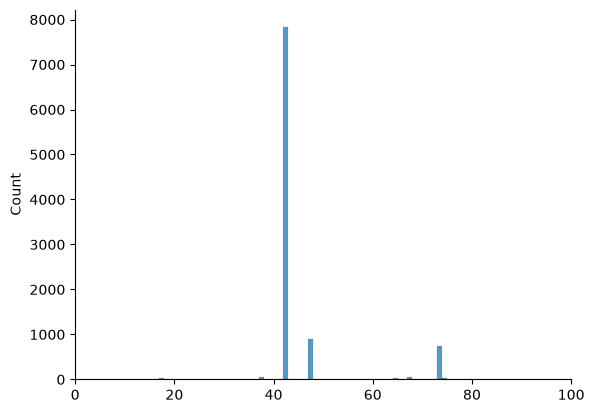

In [66]:
ax = sns.histplot(numbers, binwidth=1)
ax.set_xlim(0,100)
sns.despine()

### Task 3b: What happens if you use a low temperature?

In [67]:
messages = [
    {"role": "system", "content": "You are a helpful assistant generating random integer between 1 and 100. You only answer with a single integer, with no additional text. Make the number actually random."},
    {"role": "user", "content": "Generate a random integer between 1 and 100."}
]

sampling_params = SamplingParams(max_tokens=10, temperature=0.1)
outputs = llm.chat([messages]*10000, sampling_params=sampling_params, chat_template_kwargs={"enable_thinking": False})

Rendering conversations:   0%|          | 0/10000 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 10000/10000 [00:30<00:00, 332.98it/s, est. speed input: 21977.34 toks/s, output: 998.97 toks/s]   


In [68]:
numbers = []
for output in outputs:
    # casting to int might fail if Qwen did produce something else than just a number
    try:
        number = int(output.outputs[0].text)
        numbers.append(number)
    except:
        # simply ignore invalid responses for now
        pass

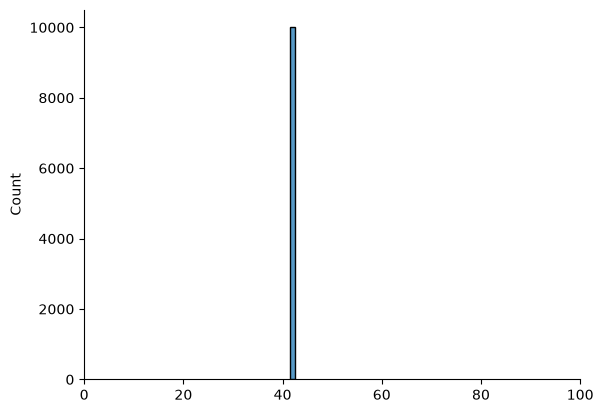

In [69]:
ax = sns.histplot(numbers)
ax.set_xlim(0,100)
sns.despine()

## Part 4: Structured Outputs

As you might have notices in Task 3, language models might not always adhere to the formatting instructions that we provide. This is especially problematic if we have a more complicated output structure such as the following JSON:

```json
{
    "id": <an integer>,
    "first name": <a string>,
    "email": <a valid email address>,
    "gender": <'female'/'male'/'non-binary'>
}
```

In [54]:
json_format = """
{
    "id": <an integer>,
    "first_name": <a string>,
    "email": <a valid email address>,
    "gender": <"female"/"male"/"non-binary">
}
"""

messages = [
    {"role": "system", "content": "You are a helpful assistant generating database entries in the following JSON format:" + json_format},
    {"role": "user", "content": "Generate an entry for Maxi Mustermann."}
]

sampling_params = SamplingParams(max_tokens=200, temperature=1.2, seed=2)
outputs = llm.chat(messages, sampling_params=sampling_params, chat_template_kwargs={"enable_thinking": False})

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.16it/s, est. speed input: 193.07 toks/s, output: 117.14 toks/s]


In [55]:
print(outputs[0].outputs[0].text)

```json
{
    "id": 194039,
    "first_name": "Maxi",
    "email": "maxi.mustermann@example.com",
    "gender": "non-binary"
}
```


Even if Qwen3.5-4B might have tried to provide some useful context here, we would not be able to directly parse the generated text with `json.loads()`. However, we can **force vllm to adhere to the desired output format by restricting the model's vocabulary** at each step of the text generation. This is called *Structured Outputs* - see also the [vllm documentation](https://docs.vllm.ai/en/stable/features/structured_outputs.html).

With vllm, we can for instance restrict the output to a choice from a list of answer options:

In [58]:
from vllm.sampling_params import StructuredOutputsParams

structured_output_params = StructuredOutputsParams(choice=["Positive", "Negative"])
sampling_params = SamplingParams(structured_outputs=structured_output_params, seed=1)

outputs = llm.generate(
    prompts="Classify this sentiment: Mannheim is wonderful!",
    sampling_params=sampling_params,
)
print(outputs[0].outputs[0].text)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:03<00:00,  3.06s/it, est. speed input: 2.95 toks/s, output: 0.65 toks/s]

Positive


To get a more elaborate JSON output pattern, we can define the desired output as a class using [PyDantic](https://docs.pydantic.dev/latest/):

In [59]:
from pydantic import BaseModel, EmailStr
from enum import Enum

class GenderType(str, Enum):
    female = "female"
    male = "male"
    non_binary = "non-binary"

class DatabaseEntry(BaseModel):
    id: int
    first_name: str
    email: EmailStr # a special type for validating email addresses
    gender: GenderType # one of the choices from the enum above

In [60]:
json_format = """
{
    "id": <an integer>,
    "first_name": <a string>,
    "email": <a valid email address>,
    "gender": <"female"/"male"/"non-binary">
}
"""

messages = [
    {"role": "system", "content": "You are a helpful assistant generating database entries in the following JSON format:" + json_format},
    {"role": "user", "content": "Generate an entry for Maxi Mustermann."}
]

structured_output_params = StructuredOutputsParams(json=DatabaseEntry.model_json_schema())
sampling_params = SamplingParams(max_tokens=200, temperature=1.2, seed=2, structured_outputs=structured_output_params)
outputs = llm.chat(messages, sampling_params=sampling_params)

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.70it/s, est. speed input: 235.58 toks/s, output: 108.31 toks/s]


In [61]:
print(outputs[0].outputs[0].text)

{ "id": 1029374, "first_name": "Maxi", "email": "maximustermann@example.com", "gender": "male" }


Note that most other inference providers (such as the OpenAI API) **only offer structured outputs with json schema.**

Also note that the **model is not "aware" of the pattern**, so you should still write an appropriate formatting instruction in the system/user prompt and just use structured outputs additionally.

### Task 4: Ask Qwen3.5-4B for a Verbalized Distribution of Survey Answers

Simulate survey responses for Germany on question Q113 of the [World Value Survey (wave 7)](https://www.worldvaluessurvey.org/WVSDocumentationWV7.jsp). Use structured outputs to obtain probabilities for all possible answer options.

In [62]:
class AnwerOptions(BaseModel):
    A: float
    B: float
    C: float
    D: float

json_format = """
{
    "A": <probability>,
    "B": <probability>,
    "C": <probability>,
    "D": <probability>
}
"""

system_prompt = """You are a political scientist predicting survey responses for Germany to the following survey question:
'Among the state authorities, how many do you believe are involved in corruption? Tell me for each group if you believe it is none of them, few of them, most of them or all of them?'

These are the answer options: [A: None of them, B: Few of them, C: Most of them, D: All of them]
You predict probabilities for each answer option and answer in the following JSON format:""" + json_format

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": 'Among the state authorities, how many do you believe are involved in corruption? Tell me for each group if you believe it is none of them, few of them, most of them or all of them?'}
]

structured_output_params = StructuredOutputsParams(json=AnwerOptions.model_json_schema())
sampling_params = SamplingParams(max_tokens=200, seed=42, structured_outputs=structured_output_params)
outputs = llm.chat(messages, sampling_params=sampling_params)

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.72it/s, est. speed input: 542.88 toks/s, output: 128.22 toks/s]


In [63]:
print(outputs[0].outputs[0].text)

{
    "A": 0.42,
    "B": 0.32,
    "C": 0.18,
    "D": 0.04
}
